In [1]:
from mpi4py import MPI
import coqui

# Create CoQui MPI handler and set logging verbosity in the beginning
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


## From DFT to CoQui

<figure style="text-align: center;">
 <img src="../../images/coqui_workflow_wan90.png" alt="Workflow of CoQuí" width="60%">
</figure>

This notebook covers the entry point of a CoQuí many-body workflow: preparing reusable inputs from DFT results.

#### 🔹 Two necessary ingredients CoQuí needs

1. Crystal metadata (k-mesh, lattice, pseudopotentials, unit-cell information).

2. Single-particle Bloch orbitals used as the basis of the interacting many-electron problem. In practice, orbitals usually come from a mean-field method such as DFT, HF, or related single-particle approaches.

> Note: You can also start from a pre-optimized localized basis (for example, Gaussian-type orbitals), as long as the metadata and orbitals are provided in a supported format.

#### 🔹 Why MLWFs appear in this workflow?

Maximally localized Wannier functions (MLWFs) [[1](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.65.035109), [2](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.56.12847)] are a key bridge between different CoQuí components. 

They are especially useful for:

- interpolation on dense k-meshes;
- defining physically motivated correlated subspaces for quantum embedding.

#### 🔹 What this notebook covers

1. Convert DFT outputs (Quantum ESPRESSO in this notebook) into CoQuí format with `pw2coqui.x`.

2. Declare the physical system through `coqui.Mf` (CoQuí's mean-field data container).

3. Construct MLWFs through CoQuí’s Wannier90 interface.

External learning materials:
- Quantum ESPRESSO tutorials: [official tutorials](https://www.quantum-espresso.org/learn/)

- Wannier90 references: [documentation](https://wannier90.readthedocs.io/en/latest/) 


First, let's copy the pre-computed Quantum ESPRESSO (QE) results and the necessary input files to the current directory.

In [2]:
%%bash
python copy_notebook_inputs.py

Copied: data/qe_inputs/svo/222/out -> out
Copied: data/qe_inputs/svo/222/svo.pw2coqui.in -> svo.pw2coqui.in
Copied: data/qe_inputs/svo/222/mlwf/svo.win -> mlwf/svo.win
Copied: data/qe_inputs/svo/222/mlwf_dp/svo.win -> mlwf_dp/svo.win
Notebook inputs are ready.


### Section 1: Quantum ESPRESSO converter

<figure style="text-align: center;">
 <img src="../../images/coqui_dft_converter.png" alt="Workflow of input preparation for CoQuí" width="60%">
</figure>

Electronic-structure packages such as QE, VASP, and PySCF write their results in different formats. CoQuí uses converter interfaces to translate those outputs into a unified input format for later many-body steps.

This section focuses on the Quantum ESPRESSO path and the QE converter [ `pw2coqui.x` ](https://github.com/AbInitioQHub/coqui/tree/main/qe_converter).

#### 🔹 Converter command

The QE converter is used from the command line:
>```bash
>pw2coqui.x -in {prefix}.pw2coqui.in
>```

Its minimal input file is:
>```text
>&input_pw2coqui
> prefix = "{prefix}"
> outdir = "{outdir}"
>/
>```
- `prefix` (required): QE prefix that identifies the dataset and output file names.

- `outdir` (required): QE output directory containing `{prefix}.save/`.

Running the converter generates:
- **`{prefix}.coqui.h5`**: standardized HDF5 metadata for CoQuí (k-point mesh, lattice vectors, pseudopotential information, etc.).

CoQuí also needs access to QE wavefunctions from the `nscf` step:
- **`{outdir}/{prefix}.save/`**: directory containing Kohn–Sham orbitals (`wfc*.hdf5`) used as the Bloch basis.

Together, these form the complete input for subsequent CoQuí steps.


> Important: Do not move or delete `{prefix}.save/` after conversion. Later steps require both `.coqui.h5` and `{prefix}.save/`.


#### 🔹 Example — Converting SrVO$_3$ results to CoQui format

In [3]:
%%bash
# 1. Running pw2coqui.x to convert the QE output to CoQui format
# 2. Inspect the content of the generated HDF5 file
pw2coqui.x -i svo.pw2coqui.in

# check the content of the generated HDF5 file
h5ls ./out/svo.coqui.h5/Orbitals

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------



     Program PW2AIMBES v.7.4 starts on 31May2026 at  0: 0:56 
        Git branch: master
        Last git commit: a546703a761ccaf2e961f281526947e5269d4e69-dirty
        Last git commit date: Mon Oct 21 12:38:43 2024 +0000
        Last git commit subject: Merge branch 'master-qe-v7.4' into 'master'

     This program is part of the open-source Quantum ESPRESSO suite
     for quantum simulation of materials; please cite
         "P. Giannozzi et al., J. Phys.:Condens. Matter 21 395502 (2009);
         "P. Giannozzi et al., J. Phys.:Condens. Matter 29 465901 (2017);
         "P. Giannozzi et al., J. Chem. Phys. 152 154105 (2020);
          URL http://www.quantum-espresso.org", 
     in publications or presentations arising from this work. More details at
     http://www.quantum-espresso.org/quote

     Parallel version (MPI & OpenMP), running on      32 processor cores
     Number of MPI processes:                 1
     Threads/MPI process:                    32

     MPI processes dist

### Section 2: Declaring a simulated physical system

<figure style="text-align: center;">
 <img src="../../images/coqui_workflow_mf.png" alt="Workflow of CoQuí's Mf declaration step" width="60%">
 <figcaption><em>Figure&nbsp;2:</em> The mean-field declaration step in the CoQuí workflow.</figcaption>
</figure>

A universal starting point for CoQui simulations is declaring the simulated physical system. In CoQui, a simulated system is defined by 

- metadata (lattice, k-mesh, pseudopotentials, etc.) 

- the single-particle orbitals $\phi^{\mathbf{k}}_{i}(\mathbf{r})$, 

which together determine the non-interacting Hamiltonian: 
$$
(H_{0})^{\textbf{k}}_{ij} = \int d\textbf{r} \, \phi^{\textbf{k}*}_{i}(\textbf{r}) \Big [ \frac{\nabla^{2}}{2} + V_{\mathrm{ext}}(\textbf{r}) \Big ] \phi^{\textbf{k}}_{j}(\textbf{r}),
$$

where $V_{\mathrm{ext}}$ is the external potential from the nuclei and pseudopotentials.

#### 🔹 `coqui.Mf` container

In CoQuí, the declaration of the simulated system is handled by the read-only `coqui.Mf` container, constructed through:
>```python
>coqui.make_mf(mpi: coqui.MpiHandler, params: dict, mf_type: str) -> coqui.Mf
>```

Function inputs:
- `mpi` (required): `MpiHandler` instance that carries the MPI context.

- `params` (required): dictionary containing input parameters. Important keys include:
    - `prefix` (required): QE prefix used in `scf/nscf`.

    - `outdir` (required): QE outdir containing `{prefix}.save/`.

    - `nbnd` (optional): number of imported bands. If omitted, all available bands are imported.

- `mf_type` (required): DFT-backend, currently `qe` for Quantum ESPRESSO or `pyscf` for PySCF.

The data structure of the returned `coqui.Mf` object is independent of the underlying DFT backend (QE, PySCF, etc.). `coqui.Mf` therefore serves as a universal starting point for all CoQuí calculations, providing a consistent interface across different DFT backends.

> Tip: Manipulate `nbnd` to control the number of KS orbitals for basis convergence tests and faster experimental runs. 

#### 🔹 Example — `Mf` container for SrVO$_3$ from Quantum ESPRESSO

The following example constructs a `Mf` object for SrVO$_3$ from a pre-computed DFT calculation using Quantum ESPRESSO, converted to CoQui format in the previous section.

In [4]:
# Mf for the target system
params = {
 "prefix": "svo",     # QE prefix (matches {prefix}.save)
 "outdir": "out",     # QE outdir containing {prefix}.save/
 "nbnd": 40           # number of bands imported from QE outputs
}
mf = coqui.make_mf(coqui_mpi, params=params, mf_type="qe")

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859



After building the `Mf` object above, use the log output to understand and validate the system.

**Checks**

1. Describe the system from the log output: number of KS orbitals, k-points, spins, and related metadata.

2. Cross-check with the QE [input](../../data/qe_inputs/svo/222/out/svo.nscf.in)/[output](../../data/qe_inputs/svo/222/out/svo.nscf.out) and verify that the `Mf` metadata matches the QE setup.

**Experiment** — vary `"nbnd"`:

- Remove `"nbnd"` and rebuild `Mf` to include all KS orbitals. What is the total count?

- Reintroduce `"nbnd"` with different values and verify the reported number of included orbitals.

In [13]:
# remove "nbnd"
del params["nbnd"]
mf = coqui.make_mf(coqui_mpi, params=params, mf_type="qe")

# set "nbnd" = 5
params["nbnd"] = 5
mf = coqui.make_mf(coqui_mpi, params=params, mf_type="qe")

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 100
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 5
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859



### Section 3: MLWFs from CoQuí

<figure style="text-align: center;">
 <img src="../../images/coqui_workflow_wan90.png" alt="Workflow of CoQuí's Wannier90 interface" width="60%">
 <figcaption><em>Figure&nbsp;2:</em> MLWF construction step in the CoQuí workflow.</figcaption>
</figure>

#### 🔹 What are Wannier functions?

The Bloch orbitals $\phi^{\mathbf{k}}_{i}(\mathbf{r})$ produced by a DFT calculation are delocalized over the whole crystal. Wannier functions provide an equivalent *real-space* representation, obtained from a unitary transformation of the Bloch states within a chosen set of bands:

$$
w_{n\mathbf{R}}(\mathbf{r}) = \frac{V}{(2\pi)^3}\int_{\mathrm{BZ}} d\mathbf{k}\; e^{-i\mathbf{k}\cdot\mathbf{R}} \sum_{i} U^{(\mathbf{k})}_{in}\, \phi^{\mathbf{k}}_{i}(\mathbf{r}),
$$

where $\mathbf{R}$ is a lattice vector and $U^{(\mathbf{k})}$ is a $\mathbf{k}$-dependent unitary (gauge) matrix. This gauge is not unique: *maximally localized* Wannier functions (MLWFs) [[1](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.65.035109), [2](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.56.12847)] fix it by minimizing the total real-space spread

$$
\Omega = \sum_{n} \Big[ \langle w_{n\mathbf{0}}|\, r^{2}\, |w_{n\mathbf{0}}\rangle - |\langle w_{n\mathbf{0}}|\, \mathbf{r}\, |w_{n\mathbf{0}}\rangle|^{2} \Big].
$$

The result is a set of compact, atomic-orbital-like functions centered on (or between) atoms. This localized and chemically intuitive character makes MLWFs particularly useful for 

- interpolation on dense k-meshes;

- defining physically motivated correlated subspaces for quantum embedding.

#### 🔹 Wannier90 interface

Now that we know what MLWFs are and why they are useful, let's see how to construct them in CoQuí. Rather than reimplementing the Wannierization algorithm, CoQuí drives [Wannier90](https://wannier90.readthedocs.io/en/latest/) directly from Python, so that building MLWFs becomes a native step of the same workflow.

CoQuí exposes the Wannier90 interface through:

> ```python
> coqui.wannier90(mf: coqui.Mf, params: dict)
> ```

Function inputs:
- `mf` (required): `Mf` instance for the target system.

- `params` (required): dictionary containing Wannier90 interface parameters. Important keys include:
    - `outdir` (default: `./`): Directory to read/write Wannier90 input/output files.

    - `prefix` (required): Wannier90 seedname used to locate `{outdir}/{prefix}.win` and write outputs

External parameter file:
- `{outdir}/{prefix}.win` (required): Standard Wannier90 input file present in the working directory that specifies Wannierization settings (projections, band window, number of Wannier functions, etc.). Atomic positions, lattice vectors, and k-points are filled in automatically by CoQuí and do not need to be included.

    >```text
    ># Example: svo.win
    >num_wann = 3
    >exclude_bands : 1-20,24-40
    >num_bands = 3
    >
    >begin projections
    >V:dxz,dyz,dxy:x=1,0,0
    >end projections
    >```

Output:
- `{outdir}/{prefix}.mlwf.h5`: HDF5 file storing the Wannierization results, including MLWF centers, and the corresponding projectors going from the Bloch basis to the Wannier basis. This file is the primary input for subsequent CoQuí steps that require MLWFs.

#### 🔹 Example - MLWFs for V $t_{2g}$ orbitals

In the following example, we first build the `Mf` object for SrVO$_3$ and then call `coqui.wannier90` with a prepared win file `mlwf/svo.win` to construct MLWFs for the V $t_{2g}$ orbitals.

In [6]:
!cat mlwf/svo.win

num_wann = 3
exclude_bands : 1-20,24-40
num_bands = 3

begin projections
V:dxz,dyz,dxy:x=1,0,0
end projections

num_print_cycles = 10

In [7]:
# Step 1: Build mean-field object from QE outputs
mf_params = {
    "prefix": "svo",
    "outdir": "out",
    "nbnd": 40,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Step 2: Run Wannier90 through CoQuí
w90_params = {
    "outdir": "mlwf",
    "prefix": "svo",
}
coqui.wannier90(mf=mf, params=w90_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859

*************************************************
       Running Wannier90 in library-mode         
*************************************************

Note: no parallel distribution provided (option distk missing)
Note: all k-points handled by MPI rank 0

 *---------------------------------- K-MESH ----------------------------------*
 +----------------------------------------------------------------------------+
 |                    Distance to Nearest-Neighbour Shells                    |
 |                    ------------

**Checks**

1. How many MLWFs are generated?

2. What are their spreads and centers?

#### 🔹 Wannier interpolation

<figure style="text-align: center;">
 <img src="../../images/MLWF_interpolation.png" alt="Wannier interpolation" width="70%">
 <figcaption><em>Figure&nbsp;2:</em> Wannier interpolation (figure taken from N. Marzari, et. al. RMP. 84, 1419 (2012)).</figcaption>
</figure>

A defining property of MLWFs is that they are localized in real space which implies that their Fourier transforms are smooth and slowly varying in reciprocal space. 

Concretely, when the Hamiltonian is expressed in the MLWF basis, its matrix elements $\langle w_{n\mathbf{0}}| \hat{H} | w_{m\mathbf{R}}\rangle$ decay rapidly with the cell separation $\mathbf{R}$, so only a few short-range hoppings carry essentially all of the information. Evaluating this handful of elements allows to reconstruct the bands anywhere in the Brillouin zone at negligible cost, as illustrated in the figure above.

Starting from MLWFs built on the coarse k-mesh of the original calculation, we can reconstruct smooth band dispersions along arbitrary high-symmetry paths for visualization and analysis, without any additional DFT calculation.

#### 🔹 Band interpolation

In CoQuí, band interpolation along a high-symmetry path is performed through:

> ```python
> coqui.post_proc.band_interpolation(mf: Mf, params: dict)
> ```

Here we use this routine to interpolate the **DFT (mean-field) band structure** carried by `coqui.Mf`. Keep in mind that the *same* routine is reused later in the tutorial series to interpolate **many-body band structures** (e.g. GW quasiparticle bands); what changes is only the electronic-structure data stored in the input checkpoint, not the interface itself.

Function inputs:
- `mf`: `Mf` object defining the crystal and Bloch basis for interpolation.

- `params`: Dictionary containing interpolation parameters. Key parameters include:
    - `outdir` (default: `./`): output directory for interpolated bands.

    - `prefix` (required): prefix for the hdf5 output.

    - `wannier_file` (required): path to the MLWF HDF5 file.

    - `kpath` (required): string defining the high-symmetry path in the format:
        >```text
        >KPT_LABEL_1 kx ky kz
        >KPT_LABEL_2 kx ky kz
        >...
        >```
        where `KPT_LABEL` is the label of the high-symmetry point (e.g., `G`, `X`, `M`), and `kx ky kz` are the fractional coordinates of the k-point in the reciprocal lattice.

Outputs:
- `{outdir}/{prefix}.mbpt.h5`: HDF5 checkpoint containing interpolated quantities.

- Interpolated band energies are stored under the hdf5 group:
  - `scf/iter0/wannier_inter/E_ska`

> Note: In CoQui conventions, DFT solution carried by `coqui.Mf` is always stored under `scf/iter0` hdf5 group. 

#### 🔹 Example - SrVO$_{3}$ band structure along high-symmetry k-path

In this example, we use the MLWFs constructed above to interpolate the SrVO$_3$ DFT band structure along a high-symmetry path.

At the end of the workflow, the interpolated bands are visualized using CoQuí plotting utilities (built on matplotlib).

>```python
> coqui.plot_utils.band_plot(
>    ax: matplotlib.Axes, 
>    coqui_h5: str,
>    iteration: int,
>    **kargs for styling and labeling
>)
>```

Function inputs:
- `ax` (required): Matplotlib axis object to plot on.

- `coqui_h5` (required): the checkpoint file containing interpolated bands.

- Additional keyword arguments for matplotlib to control styling (e.g., `color`, `linestyle`, `linewidth`, `label`, `fontsize`).

> Note: You can also read band data directly from `scf/iter0/wannier_inter/E_ska` in the checkpoint file and plot with your preferred plotting library. 

In [8]:
mf_params = {
    "prefix": "svo",
    "outdir": "out",
    "nbnd": 40,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Wannier interpolation for G0W0
winter_params = {
    "outdir": "./",
    "prefix": "svo",
    "wannier_file": "mlwf/svo.mlwf.h5", 
    "kpath": """
      G 0.00 0.00 0.00
      X 0.00 0.50 0.00
      M 0.50 0.50 0.00
      G 0.00 0.00 0.00
    """
}
coqui.post_proc.band_interpolation(mf, winter_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 2.938399981857951 a.u.
  Lambda                 = 2938.399981857951
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 60, 60, 60, 61

╔═╗┌─┐╔═╗ ┬ ┬┬  ╦ ╦┌─┐┌┐┌┌┐┌┬┌─┐┬─┐  ╦┌┐┌┌┬┐┌─┐┬─┐┌─┐
║  │ │║═╬╗│ ││  ║║║├─┤│││││││├┤ ├┬┘  ║│││ │ ├┤ ├┬┘├─┘
╚═╝└─┘╚═╝╚└─┘┴  ╚╩╝┴ ┴┘└┘┘└┘┴└─┘┴└─  ╩┘└┘ ┴ └─┘┴└─┴o 

  Type                       

  Plotting QP Band Structure
  --------------------------
  CoQui h5           = svo.mbpt.h5
  Iteration          = 0 (i.e. DFT bands)
  Number of spins    = 1
  Number of k-points = 342
  Number of bands    = 3
  Chemical potential = 11.744 (eV)



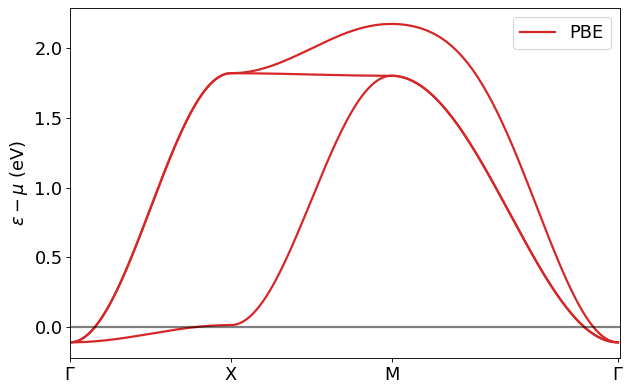

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8,5), dpi=80)
coqui.post_proc.plot_utils.band_plot(
    ax, "svo.mbpt.h5", 
    color='tab:red', linestyle="-",  
    linewidth=2.0, label='PBE', fontsize=16
)
ax.axhline(y=0, color = 'black', linestyle = '-', linewidth=2.0, alpha=0.5)
ax.legend(loc=1, fontsize=16)
plt.tight_layout()

#### 🔹 Example — MLWFs with disentanglement (V $d$ + O $p$)

In the previous example the V $t_{2g}$ bands were isolated, so they could be Wannierized directly. Here we target a larger manifold — the full V $d$ shell *and* the O $p$ states — which is entangled with other bands. Extracting localized orbitals from such a manifold requires Wannier90's *disentanglement* procedure, which first selects an optimally connected subspace from a wider band window before localization.

Goal:

1. Build MLWFs for both the V $d$ and O $p$ states using a disentanglement window.

2. Interpolate and compare the resulting band dispersion against the small-window (V $t_{2g}$) MLWF result.

Steps:

1. Compare the prepared `mlwf_dp/svo.win` against the earlier `mlwf/svo.win`, and note the differences that enable disentanglement:
    - more target orbitals (`num_wann = 14`: V $t_{2g}$ + V $e_g$ + O $p$);

    - a wider band window (`num_bands = 19`, with fewer `exclude_bands`) than the number of Wannier functions, leaving room to disentangle;

    - a frozen energy window (`dis_froz_min`/`dis_froz_max`) specifying states that must be reproduced exactly.

2. Run `coqui.wannier90` to generate the MLWF HDF5 file (`mlwf_dp/svo.mlwf.h5`).

3. Run `band_interpolation` with the disentangled Wannier file on the same $\Gamma$–$X$–$M$–$\Gamma$ path.

4. Visualize and compare the two band structures.

Checks:
- The disentangled interpolation reproduces additional O $p$-derived dispersions that are absent in the small-window case.

- Each oxygen atom contributes three localized $p$-like orbitals (`num_wann = 14` = 5 V $d$ + 3 × 3 O $p$).

- Within the frozen window, the interpolated bands match the DFT bands essentially exactly.

Reference: oxygen positions are listed in `data/qe_inputs/svo/222/out/svo.nscf.out`.

In [15]:
!cat mlwf_dp/svo.win

num_wann = 14
exclude_bands : 1-11,31-40
num_bands = 19

begin projections
V:dxz,dyz,dxy
V:dz2,dx2-y2
O:p
end projections

!dis_win_min = 2.0
!dis_win_max = 30.0
dis_froz_min = 11.5
dis_froz_max = 14.0

num_print_cycles = 10


In [16]:
# Step 1: Build mean-field object from existing QE outputs
mf_params = {
    "prefix": "svo",
    "outdir": "out",
    "nbnd": 40,
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Step 2: Run Wannier90 for the disentangled window (V d + O p)
w90_params = {
    "outdir": "mlwf_dp",
    "prefix": "svo"
}
coqui.wannier90(mf=mf, params=w90_params)

# Step 3: Interpolate bands with the disentangled Wannier file
winter_params_dp = {
    "outdir": "./",
    "prefix": "svo_dp",
    "wannier_file": "mlwf_dp/svo.mlwf.h5",
    "kpath": """
      G 0.00 0.00 0.00
      X 0.00 0.50 0.00
      M 0.50 0.50 0.00
      G 0.00 0.00 0.00
    """,
}
coqui.post_proc.band_interpolation(mf, winter_params_dp)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859

*************************************************
       Running Wannier90 in library-mode         
*************************************************

Note: no parallel distribution provided (option distk missing)
Note: all k-points handled by MPI rank 0

 *---------------------------------- K-MESH ----------------------------------*
 +----------------------------------------------------------------------------+
 |                    Distance to Nearest-Neighbour Shells                    |
 |                    ------------

  Plotting QP Band Structure
  --------------------------
  CoQui h5           = svo.mbpt.h5
  Iteration          = 0 (i.e. DFT bands)
  Number of spins    = 1
  Number of k-points = 342
  Number of bands    = 3
  Chemical potential = 11.744 (eV)

  Plotting QP Band Structure
  --------------------------
  CoQui h5           = svo_dp.mbpt.h5
  Iteration          = 0 (i.e. DFT bands)
  Number of spins    = 1
  Number of k-points = 342
  Number of bands    = 14
  Chemical potential = 11.744 (eV)



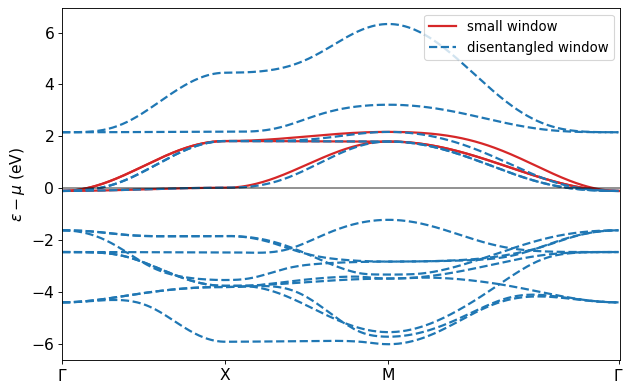

In [17]:
# Step 4: compare against the small-window result
# (requires that the small-window interpolation cell above has been run)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(8, 5), dpi=80)

coqui.post_proc.plot_utils.band_plot(
    ax,
    "svo.mbpt.h5",
    color="tab:red",
    linestyle="-",
    linewidth=2.0,
    label="small window",
    fontsize=14,
)

coqui.post_proc.plot_utils.band_plot(
    ax,
    "svo_dp.mbpt.h5",
    color="tab:blue",
    linestyle="--",
    linewidth=2.0,
    label="disentangled window",
    fontsize=14,
)

ax.axhline(y=0, color="black", linestyle="-", linewidth=1.5, alpha=0.5)
ax.legend(loc=1, fontsize=12)
plt.tight_layout()